In [2]:
# Data visualization notebook that uses the merged MASS CSV dataset to
# compare fixed- and floating-layer turbulence properties through density
# scatter plots generated by the `plot()` function.
#
# The notebook visualizes:
# 1. The summed turbulence strengths ($\sum Cn^{2}dh$) of fixed versus
#    floating layers.
# 2. The $\frac{5}{3}$ moment of $Cn^{2}dh$ for fixed versus floating
#    layers, weighted by layer height.
#
# Density coloring is applied using Gaussian kernel density estimation
# (KDE) to highlight clustering and distribution structure within the
# data.
#
# The notebook also computes additional descriptive statistics for each
# atmospheric layer, including minimum and maximum turbulence-strength
# values and related layer-based summaries.

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde
import numpy as np

In [3]:
def plot(file):

    with open(file, 'r') as f:
        data = pd.read_csv(f)

        # Part 1: Sum of the fixed layer strengths vs. sum of the floating layer strengths
        x = data['fixed_c1'] + data['fixed_c2'] + data['fixed_c3'] + \
            data['fixed_c4'] + data['fixed_c5'] + data['fixed_c6'] # Fixed Layers
        
        y = data['float_c1'] + data['float_c2'] + data['float_c3'] # Floating layers

        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)
        
        plt.figure(figsize=(6,4))
        plt.title(r"$\sum Cn^{2}dh$ (Fixed vs. Floating)")
        plt.xlabel("Fixed Layer")
        plt.ylabel("Floating Layer")
        plt.scatter(x, y, c=z)
        plt.colorbar(label='Density')
        plt.xlim(0,1e-12)
        plt.ylim(0,1e-12)
        plt.grid()
        plt.show()

        # Part 2: Sum of the Cn2dh^(5/3) for fixed layers vs. floating layers - the 5/3 moment of Cn2
        x = data['fixed_c1']*data['fixed_h1']**(5/3) + \
            data['fixed_c2']*data['fixed_h2']**(5/3) + \
            data['fixed_c3']*data['fixed_h3']**(5/3) + \
            data['fixed_c4']*data['fixed_h4']**(5/3) + \
            data['fixed_c5']*data['fixed_h5']**(5/3) + \
            data['fixed_c6']*data['fixed_h6']**(5/3) # Fixed Layers
        
        y = data['float_c1']*data['float_h1']**(5/3) + \
            data['float_c2']*data['float_h2']**(5/3) + \
            data['float_c3']*data['float_h3']**(5/3) # Floating Layers 

        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)

        plt.figure(figsize=(6,4))
        plt.title(r"$\frac{5}{3}$ moment of $Cn^{2}dh$ (Fixed vs. Floating)")
        plt.xlabel("Fixed Layer")
        plt.ylabel("Floating Layer")
        plt.scatter(x, y, c=z)
        plt.colorbar(label='Density')
        plt.xlim(0,5e-12)
        plt.ylim(0,5e-12)
        plt.grid()
        plt.show()

In [47]:
filename = "./MASS_files/2018_floating.csv"
data = pd.read_csv(filename)

print('For the year 2018:')
print('Fixed Layers')
print('1st layer --> Max: ' + str(max(data['fixed_c1'])) + ' -- Min: ' + str(min(data['fixed_c1'])))
print('2nd layer --> Max: ' + str(max(data['fixed_c2'])) + ' -- Min: ' + str(min(data['fixed_c2'])))
print('3rd layer --> Max: ' + str(max(data['fixed_c3'])) + ' -- Min: ' + str(min(data['fixed_c3'])))
print('4th layer --> Max: ' + str(max(data['fixed_c4'])) + ' -- Min: ' + str(min(data['fixed_c4'])))
print('5th layer --> Max: ' + str(max(data['fixed_c5'])) + ' -- Min: ' + str(min(data['fixed_c5'])))
print('6th layer --> Max: ' + str(max(data['fixed_c6'])) + ' -- Min: ' + str(min(data['fixed_c6'])))
print('Seeing Value --> Max: ' + str(max(data['fixed_seeing'])) + ' -- Min: ' + str(min(data['fixed_seeing'])))

print('------')

print('Floating Layers')
print('1st layer --> Max: ' + str(max(data['float_c1'])) + ' -- Min: ' + str(min(data['float_c1'])))
print('2nd layer --> Max: ' + str(max(data['float_c2'])) + ' -- Min: ' + str(min(data['float_c2'])))
print('3rd layer --> Max: ' + str(max(data['float_c3'])) + ' -- Min: ' + str(min(data['float_c3'])))
print('Seeing Value --> Max: ' + str(max(data['floating_seeing'])) + ' -- Min: ' + str(min(data['floating_seeing'])))

For the year 2018:
Fixed Layers
1st layer --> Max: 2.07e-11 -- Min: 1.22e-28
2nd layer --> Max: 3.37e-12 -- Min: 1.2100000000000001e-29
3rd layer --> Max: 6.37e-12 -- Min: 7.82e-30
4th layer --> Max: 2.06e-12 -- Min: 2.7e-26
5th layer --> Max: 2.32e-12 -- Min: 5.020000000000001e-27
6th layer --> Max: 1.4e-12 -- Min: 1.44e-29
Seeing Value --> Max: 7.84 -- Min: 0.04
------
Floating Layers
1st layer --> Max: 10000.0 -- Min: 0.0
2nd layer --> Max: 200.0 -- Min: 0.0
3rd layer --> Max: 200.0 -- Min: 0.0
Seeing Value --> Max: 5.9 -- Min: 0.0


In [51]:
count = 0
for i in data['float_c3']:
    if i > 1:
        count += 1
print(count)

10


In [52]:
data = data[data["float_c3"] <= 0.5]
data = data.dropna()

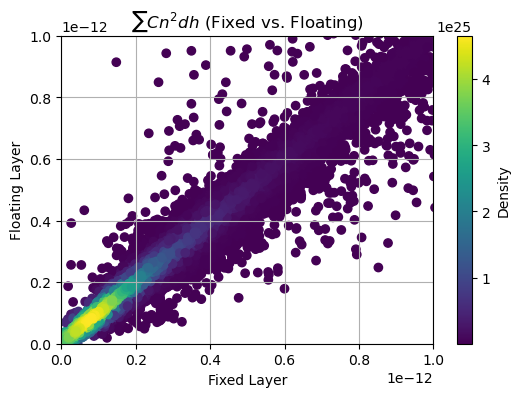

In [53]:
# Part 1: Sum of the fixed layer strengths vs. sum of the floating layer strengths
x = data['fixed_c1'] + data['fixed_c2'] + data['fixed_c3'] + \
    data['fixed_c4'] + data['fixed_c5'] + data['fixed_c6'] # Fixed Layers

y = data['float_c1'] + data['float_c2'] + data['float_c3'] # Floating layers

xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(6,4))
plt.title(r"$\sum Cn^{2}dh$ (Fixed vs. Floating)")
plt.xlabel("Fixed Layer")
plt.ylabel("Floating Layer")
plt.scatter(x, y, c=z)
plt.colorbar(label='Density')
plt.xlim(0,1e-12)
plt.ylim(0,1e-12)
plt.grid()
plt.show()

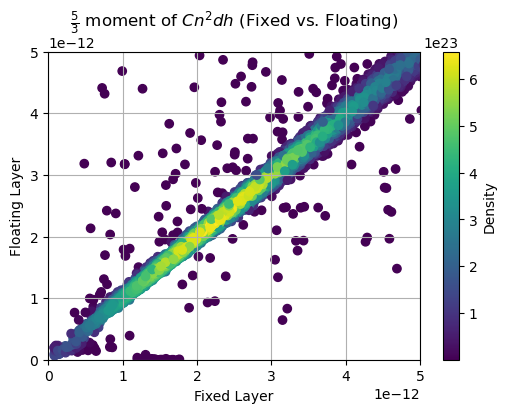

In [54]:
# Part 2: Sum of the Cn2dh^(5/3) for fixed layers vs. floating layers - the 5/3 moment of Cn2
x = data['fixed_c1']*data['fixed_h1']**(5/3) + \
    data['fixed_c2']*data['fixed_h2']**(5/3) + \
    data['fixed_c3']*data['fixed_h3']**(5/3) + \
    data['fixed_c4']*data['fixed_h4']**(5/3) + \
    data['fixed_c5']*data['fixed_h5']**(5/3) + \
    data['fixed_c6']*data['fixed_h6']**(5/3) # Fixed Layers

y = data['float_c1']*data['float_h1']**(5/3) + \
    data['float_c2']*data['float_h2']**(5/3) + \
    data['float_c3']*data['float_h3']**(5/3) # Floating Layers 

xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(6,4))
plt.title(r"$\frac{5}{3}$ moment of $Cn^{2}dh$ (Fixed vs. Floating)")
plt.xlabel("Fixed Layer")
plt.ylabel("Floating Layer")
plt.scatter(x, y, c=z)
plt.colorbar(label='Density')
plt.xlim(0,5e-12)
plt.ylim(0,5e-12)
plt.grid()
plt.show()

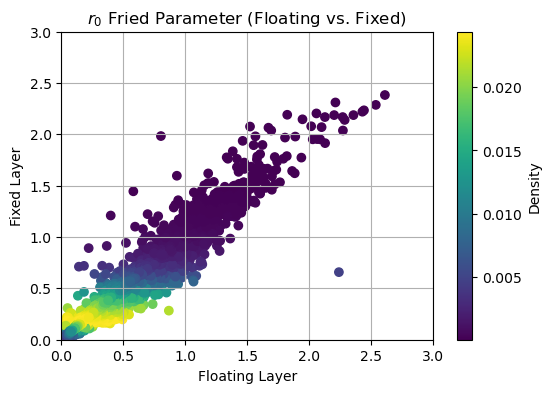

In [56]:
#r0 plots

x = data['fixed_c1'] + data['fixed_c2'] + data['fixed_c3'] + \
    data['fixed_c4'] + data['fixed_c5'] + data['fixed_c6'] # Fixed Layers

y = data['float_c1'] + data['float_c2'] + data['float_c3'] # Floating layers

r0_fixed = ( 0.423 * (2*np.pi/0.5e-6)**2. * x ) ** (-3/5.)

r0_float = ( 0.423 * (2*np.pi/0.5e-6)**2. * y ) ** (-3/5.)

xy = np.vstack([r0_float, r0_fixed])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(6,4))
plt.title(r"$r_{0}$ Fried Parameter (Floating vs. Fixed)")
plt.xlabel("Floating Layer")
plt.ylabel("Fixed Layer")
plt.scatter(r0_float, r0_fixed, c=z)
plt.colorbar(label='Density')
plt.xlim(0,3)
plt.ylim(0,3)
plt.grid()
plt.show()